# Lab 3 Demo: From Uniform Numbers to Model Inputs

We will transform uniform random numbers into categorical choices and service times, compare manual and package methods, and build a small conditional-input model.

The demo deliberately uses seed `42`, a mean service time of `2.5`, and a different accept-reject target from the assessed notebook.

## Part 0: Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_SEED = 42
#plt.style.use("seaborn-v0_8-whitegrid")

## Demo 1: A Uniform Number Is a Position on the Probability Scale

A uniform value does not yet mean *coffee*, *matcha*, or *three minutes*. It tells us where a random outcome lies on a cumulative probability scale from 0 to 1.

**Predict before running:** if the cut points are 0.50 and 0.80, which category contains `U = 0.72`?

In [2]:
demo_u = np.array([0.08, 0.49, 0.50, 0.72, 0.80, 0.96])
demo_drinks = np.array(["Coffee", "Tea", "Matcha"])
demo_probabilities = np.array([0.50, 0.30, 0.20])
# np.cumsum turns probabilities into the cumulative-CDF cut points.
demo_cut_points = np.cumsum(demo_probabilities)

# searchsorted returns the first cut point >= each U (the discrete inverse CDF).
category_index = np.searchsorted(demo_cut_points, demo_u, side="left")
# minimum is a defensive guard against an index outside the final category.
category_index = np.minimum(category_index, len(demo_drinks) - 1)

pd.DataFrame({
    "U": demo_u,
    "Assigned drink": demo_drinks[category_index],
})

,U,Assigned drink
0,0.08,Coffee
1,0.49,Coffee
2,0.50,Coffee
3,0.72,Tea
4,0.80,Tea
5,0.96,Matcha


Using the generalised-inverse rule, select the first cumulative cut point greater than or equal to `U`. Therefore `0.72` maps to Tea. With `side="left"`, a value exactly on a cut point (such as `0.50`) goes to the earlier category; exact boundary values have probability zero for a continuous uniform generator.

## Demo 2: Trace the Exponential Inverse Transform

For an exponential service time with mean `2.5` minutes:

```text
lambda = 1 / mean_service
X = -log(1 - U) / lambda
```

**Predict before running:** as `U` moves closer to 1, should the transformed service time become shorter or longer?

In [3]:
demo_mean_service = 2.5
demo_rate = 1 / demo_mean_service
trace_u = np.array([0.10, 0.25, 0.50, 0.75, 0.90, 0.99])
# log1p(z) accurately computes log(1 + z), so log1p(-U) is log(1 - U).
trace_service = -np.log1p(-trace_u) / demo_rate

pd.DataFrame({
    "U": trace_u,
    "1 - U": 1 - trace_u,
    "Service time (minutes)": trace_service,
}).round(4)

,U,1 - U,Service time (minutes)
0,0.10,0.90,0.2634
1,0.25,0.75,0.7192
2,0.50,0.50,1.7329
3,0.75,0.25,3.4657
4,0.90,0.10,5.7565
5,0.99,0.01,11.5129


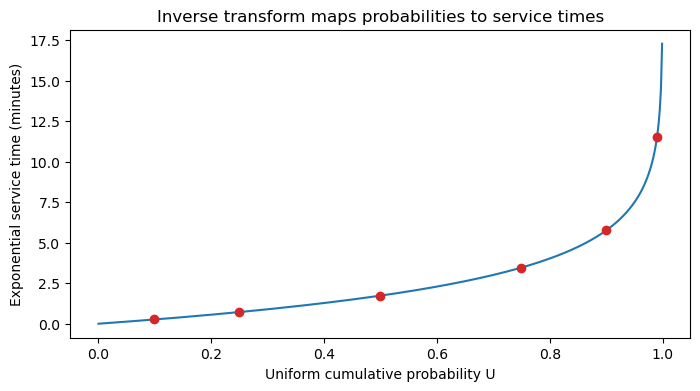

In [4]:
# linspace creates 500 evenly spaced probabilities for a smooth curve.
probability_grid = np.linspace(0.001, 0.999, 500)
quantile_grid = -np.log1p(-probability_grid) / demo_rate

plt.figure(figsize=(8, 4))
plt.plot(probability_grid, quantile_grid)
plt.scatter(trace_u, trace_service, color="tab:red", zorder=3)
plt.xlabel("Uniform cumulative probability U")
plt.ylabel("Exponential service time (minutes)")
plt.title("Inverse transform maps probabilities to service times")
plt.show()

Values near 1 represent the upper tail, so they map to long service times. The curve also explains the right-skewed histogram: much of the probability scale maps to short times, while a narrow region near 1 maps to very long times.

## Demo 3: A Sample Does Not Exactly Equal Its Distribution

The model mean is `2.5` minutes. A random sample mean will usually be close, but it will not normally equal `2.5` exactly.

In [5]:
# default_rng creates an independent, reproducible NumPy random generator.
rng = np.random.default_rng(DEMO_SEED)
sample_sizes = [10, 100, 1000, 10000]
sample_rows = []

for sample_size in sample_sizes:
    u = rng.random(sample_size)
    values = -np.log1p(-u) / demo_rate
    sample_rows.append({
        "Sample size": sample_size,
        "Sample mean": values.mean(),
        "Sample standard deviation": values.std(ddof=1),
        "Maximum": values.max(),
    })

pd.DataFrame(sample_rows).round(4)

,Sample size,Sample mean,Sample standard deviation,Maximum
0,10,3.1847,2.6591,9.2852
1,100,2.2362,1.9966,8.8253
2,1000,2.5259,2.5565,17.5460
3,10000,2.4980,2.5298,26.7023


A larger sample is generally more stable, but it is not guaranteed to be closer for every seed. The distribution describes long-run behaviour, not an exact promise for each finite sample.

## Demo 4: Manual Generation versus NumPy

We now compare the transparent manual transformation with NumPy's tested package generator. Compare the *distributions*, not element-by-element equality.

In [6]:
comparison_size = 2000

# Recreate the same starting seed for a controlled method comparison.
manual_rng = np.random.default_rng(DEMO_SEED)
manual_u = manual_rng.random(comparison_size)
manual_service = -np.log1p(-manual_u) / demo_rate

package_rng = np.random.default_rng(DEMO_SEED)
# NumPy's exponential scale parameter is the mean, not the rate.
package_service = package_rng.exponential(
    scale=demo_mean_service, size=comparison_size
)

method_summary = pd.DataFrame({
    "Method": ["Manual inverse transform", "NumPy exponential"],
    "Mean": [manual_service.mean(), package_service.mean()],
    "Sample SD": [manual_service.std(ddof=1), package_service.std(ddof=1)],
    "Minimum": [manual_service.min(), package_service.min()],
    "Maximum": [manual_service.max(), package_service.max()],
})
method_summary.round(4)

,Method,Mean,Sample SD,Minimum,Maximum
0,Manual inverse transform,2.5463,2.5667,0.0013,18.6394
1,NumPy exponential,2.5375,2.5671,0.0002,19.0367


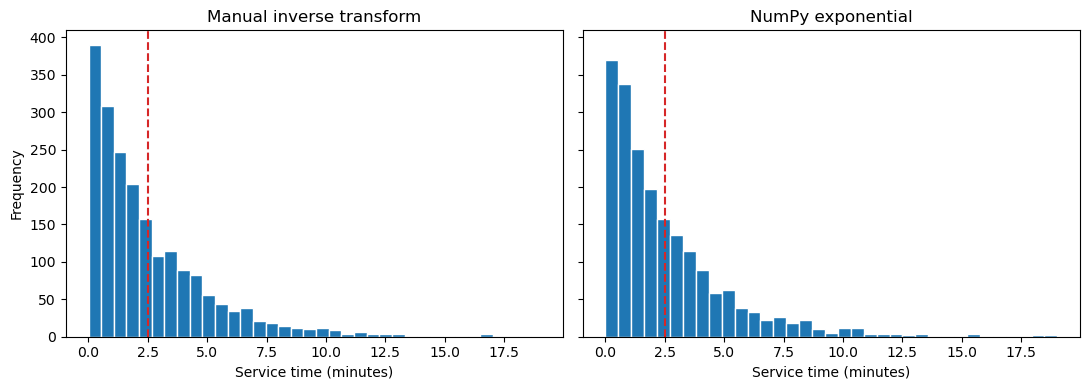

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
axes[0].hist(manual_service, bins=35, edgecolor="white")
axes[0].axvline(demo_mean_service, color="tab:red", linestyle="--")
axes[0].set_title("Manual inverse transform")
axes[1].hist(package_service, bins=35, edgecolor="white")
axes[1].axvline(demo_mean_service, color="tab:red", linestyle="--")
axes[1].set_title("NumPy exponential")
for ax in axes:
    ax.set_xlabel("Service time (minutes)")
axes[0].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

The two methods need not return identical arrays even when they start from the same seed. Similar shape, range, mean, and standard deviation provide evidence that they represent the same model distribution.

## Demo 5: What the Exponential `scale` Parameter Does

NumPy uses `scale` for the exponential mean. It does **not** use the rate `lambda`. We reuse the same uniform values so the effect of changing the mean is easy to see.

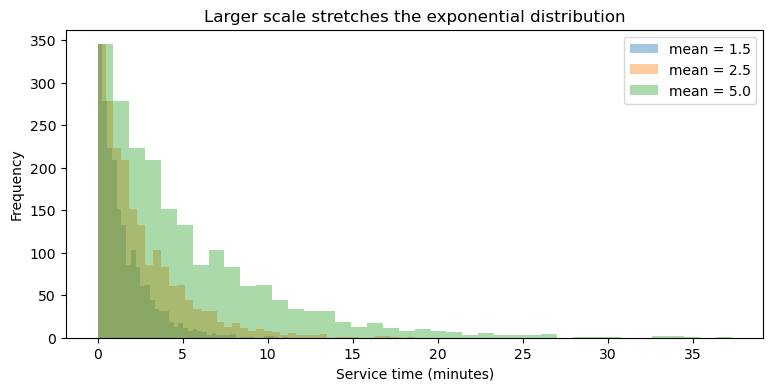

,Model mean,Sample mean
0,1.5,1.5278
1,2.5,2.5463
2,5.0,5.0926


In [8]:
scale_rng = np.random.default_rng(DEMO_SEED)
shared_u = scale_rng.random(2000)
means_to_compare = [1.5, 2.5, 5.0]

fig, ax = plt.subplots(figsize=(9, 4))
scale_rows = []
for mean_value in means_to_compare:
    # Reusing shared_u isolates the effect of changing only the model mean.
    values = -mean_value * np.log1p(-shared_u)
    ax.hist(values, bins=40, alpha=0.40, label=f"mean = {mean_value}")
    scale_rows.append({"Model mean": mean_value, "Sample mean": values.mean()})

ax.set_xlabel("Service time (minutes)")
ax.set_ylabel("Frequency")
ax.set_title("Larger scale stretches the exponential distribution")
ax.legend()
plt.show()
pd.DataFrame(scale_rows).round(4)

## Demo 6: Accept-Reject Sampling with a Different Target

For the demo, use the target density `f(x) = 3x^2` on `[0, 1]`. Propose `x` and `u` independently from `Uniform(0, 1)` and accept when `u <= x^2`.

**Predict before running:** should accepted values concentrate near 0 or near 1? Should the acceptance rate be closer to one third, one half, or two thirds?

In [9]:
accept_rng = np.random.default_rng(DEMO_SEED)
target_accepts = 1500
accepted_values = []
proposal_x = []
proposal_u = []
proposal_was_accepted = []

# Keep proposing until the required number has been accepted.
while len(accepted_values) < target_accepts:
    x = accept_rng.random()
    u = accept_rng.random()
    # This rule accepts large x more often and creates density f(x)=3x^2.
    accepted = u <= x**2
    proposal_x.append(x)
    proposal_u.append(u)
    proposal_was_accepted.append(accepted)
    if accepted:
        accepted_values.append(x)

# asarray converts Python lists to arrays for vectorised summaries and plotting.
accepted_values = np.asarray(accepted_values)
proposal_was_accepted = np.asarray(proposal_was_accepted)
acceptance_rate = len(accepted_values) / len(proposal_x)

pd.DataFrame({
    "Accepted values": [len(accepted_values)],
    "Total proposals": [len(proposal_x)],
    "Acceptance rate": [acceptance_rate],
    "Sample mean": [accepted_values.mean()],
}).round(4)

,Accepted values,Total proposals,Acceptance rate,Sample mean
0,1500,4556,0.3292,0.7433


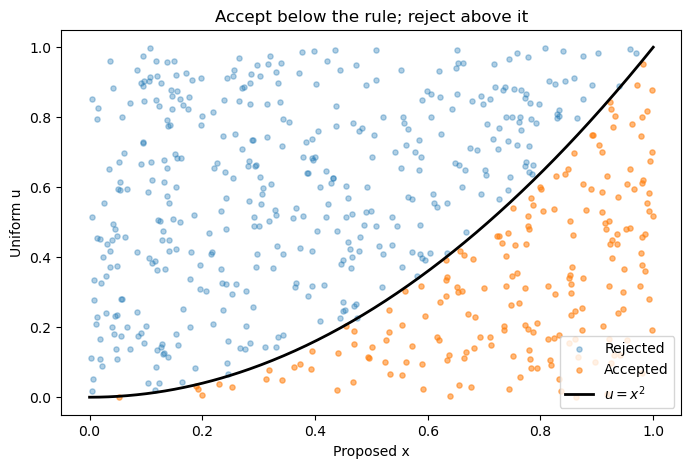

In [10]:
shown = 600
shown_x = np.asarray(proposal_x[:shown])
shown_u = np.asarray(proposal_u[:shown])
shown_accept = proposal_was_accepted[:shown]
curve_x = np.linspace(0, 1, 300)

plt.figure(figsize=(8, 5))
plt.scatter(shown_x[~shown_accept], shown_u[~shown_accept], s=14, alpha=0.35, label="Rejected")
plt.scatter(shown_x[shown_accept], shown_u[shown_accept], s=14, alpha=0.55, label="Accepted")
plt.plot(curve_x, curve_x**2, color="black", linewidth=2, label=r"$u=x^2$")
plt.xlabel("Proposed x")
plt.ylabel("Uniform u")
plt.title("Accept below the rule; reject above it")
plt.legend()
plt.show()

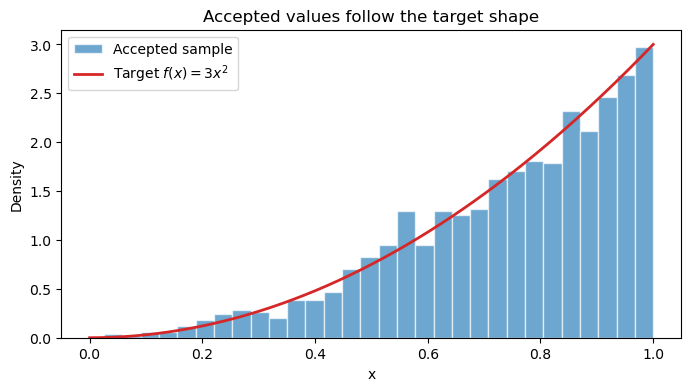

In [11]:
density_x = np.linspace(0, 1, 300)
plt.figure(figsize=(8, 4))
plt.hist(accepted_values, bins=30, density=True, alpha=0.65, edgecolor="white", label="Accepted sample")
plt.plot(density_x, 3 * density_x**2, color="tab:red", linewidth=2, label=r"Target $f(x)=3x^2$")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Accepted values follow the target shape")
plt.legend()
plt.show()

Rejection is not an error. The rule deliberately keeps proposals with different probabilities, reshaping a uniform proposal into the target distribution. Here the theoretical acceptance rate is `1/3` and the theoretical mean is `3/4`.

## Demo 7: Generate Service Time Conditional on Drink Choice

A mixed coffee-shop model needs two linked random variables:

```text
drink choice -> selects a service-time mean -> service-time draw
```

The demo uses three drinks and parameters that differ from the assessed task.

In [12]:
menu = np.array(["Espresso", "Iced tea", "Blended drink"])
menu_probabilities = np.array([0.45, 0.35, 0.20])
menu_means = {"Espresso": 1.2, "Iced tea": 1.8, "Blended drink": 4.5}
demo_customers = 2000

menu_rng = np.random.default_rng(DEMO_SEED)
# choice is the package shortcut; Demo 1 shows its discrete inverse-CDF logic.
orders = menu_rng.choice(menu, size=demo_customers, p=menu_probabilities)
# The list comprehension looks up the correct mean for every selected drink.
customer_means = np.array([menu_means[drink] for drink in orders])
# Passing an array of scales generates one conditional service time per customer.
service_times = menu_rng.exponential(scale=customer_means)

demo_customers_df = pd.DataFrame({
    "Customer": np.arange(1, demo_customers + 1),
    "Drink": orders,
    "Model mean": customer_means,
    "Service time": service_times,
})
demo_customers_df.head(10)

,Customer,Drink,Model mean,Service time
0,1,Iced tea,1.8,3.524858
1,2,Espresso,1.2,0.214918
2,3,Blended drink,4.5,6.638869
3,4,Iced tea,1.8,4.998777
4,5,Espresso,1.2,0.183277
5,6,Blended drink,4.5,7.935587
6,7,Iced tea,1.8,0.545083
7,8,Iced tea,1.8,0.220304
8,9,Espresso,1.2,0.123991
9,10,Iced tea,1.8,0.934532


In [13]:
# groupby splits customers by drink; agg calculates several summaries per group.
drink_summary = (
    demo_customers_df.groupby("Drink", sort=False)
    .agg(
        Count=("Drink", "size"),
        Average_service=("Service time", "mean"),
        Longest_service=("Service time", "max"),
    )
)
drink_summary["Simulated proportion"] = drink_summary["Count"] / demo_customers
drink_summary.round(4)

,Count,Average_service,Longest_service,Simulated proportion
Drink,,,,
Iced tea,690,1.7050,11.4109,0.3450
Espresso,897,1.1767,8.7766,0.4485
Blended drink,413,4.4346,42.8315,0.2065


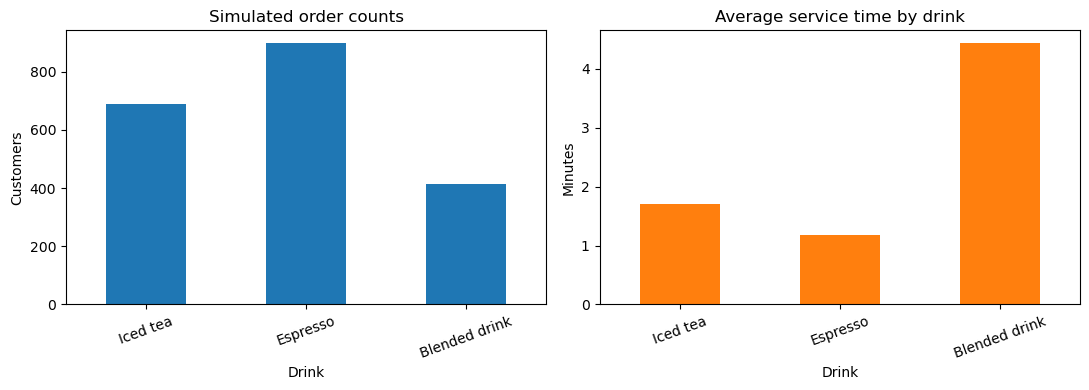

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
drink_summary["Count"].plot.bar(ax=axes[0], color="tab:blue")
axes[0].set_title("Simulated order counts")
axes[0].set_ylabel("Customers")
axes[0].tick_params(axis="x", rotation=20)
drink_summary["Average_service"].plot.bar(ax=axes[1], color="tab:orange")
axes[1].set_title("Average service time by drink")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

Drink choice must be generated first because it selects the appropriate service-time model. A category can be relatively uncommon yet contribute heavily to workload when its service-time mean is large.

## Demo 8: Compare a Baseline and a Trend Scenario

The trend shifts probability toward the slow blended drink. We use common underlying uniform values in both scenarios so that the comparison focuses on the changed probabilities rather than unrelated random noise.

In [15]:
baseline_probabilities = np.array([0.45, 0.35, 0.20])
trend_probabilities = np.array([0.30, 0.25, 0.45])
scenario_rng = np.random.default_rng(DEMO_SEED)
# Common uniform values make the two scenarios directly comparable.
choice_u = scenario_rng.random(demo_customers)
service_u = scenario_rng.random(demo_customers)

def simulate_menu_from_uniforms(probabilities, choice_uniforms, service_uniforms):
    # Convert category probabilities into cumulative-CDF cut points.
    cut_points = np.cumsum(probabilities)
    # side="left" selects the first cut point >= U, matching Demo 1.
    indices = np.searchsorted(cut_points, choice_uniforms, side="left")
    selected = menu[indices]
    # Select each customer's exponential mean from the drink dictionary.
    scales = np.array([menu_means[drink] for drink in selected])
    # Apply inverse transform element by element using those conditional means.
    times = -scales * np.log1p(-service_uniforms)
    return selected, times

baseline_orders, baseline_times = simulate_menu_from_uniforms(
    baseline_probabilities, choice_u, service_u
)
trend_orders, trend_times = simulate_menu_from_uniforms(
    trend_probabilities, choice_u, service_u
)

scenario_summary = pd.DataFrame({
    "Scenario": ["Baseline", "Blended-drink trend"],
    "Blended orders": [
        np.sum(baseline_orders == "Blended drink"),
        np.sum(trend_orders == "Blended drink"),
    ],
    "Average service time": [baseline_times.mean(), trend_times.mean()],
    "Longest service time": [baseline_times.max(), trend_times.max()],
})
scenario_summary.round(4)

,Scenario,Blended orders,Average service time,Longest service time
0,Baseline,413,2.0665,31.2687
1,Blended-drink trend,906,2.8247,37.6081


### Demo 8A: Predict the Change with a Weighted Expectation

Before relying on a random sample, calculate the model's expected service time with $E[T]=\sum_j p_j\mu_j$. This is the calculation required in assessed Part E.

In [16]:
# Build the mean vector in exactly the same order as the menu probabilities.
menu_mean_vector = np.array([menu_means[drink] for drink in menu])

# The @ operator computes the dot product sum(p_j * mu_j).
baseline_expected = baseline_probabilities @ menu_mean_vector
trend_expected = trend_probabilities @ menu_mean_vector

expectation_summary = pd.DataFrame({
    "Scenario": ["Baseline", "Blended-drink trend"],
    "Expected service time": [baseline_expected, trend_expected],
    "Change from baseline": [0.0, trend_expected - baseline_expected],
})
expectation_summary.round(4)

                 Scenario  Expected service time  Change from baseline
0                Baseline                  2.070                 0.000
1  Blended-drink trend                  2.835                 0.765

The expectation gives the long-run workload implied by the model inputs. The simulated average should be reasonably close, while the sample maximum can move unpredictably because it is highly variable.

**Instructor prompt:** which column provides the clearest evidence of a workload change? What operational action would you recommend, and what additional real data would you want before making the decision?

## Demo 9: Model a Strong Interpretation

A strong interpretation connects assumption, evidence, and consequence:

> The trend scenario assigns more customers to the slowest drink category. In this reproducible comparison, the simulated average service demand per customer increases. If arrivals and staffing stay unchanged, barista utilisation and waiting are likely to rise. The manager could test advance preparation or an additional trained worker during peak periods.

Avoid claims such as “the trend definitely creates a queue.” This lab generates inputs; a later discrete-event model will calculate queue behaviour.

## Transfer Map to the Assessed Lab

| Demo idea | Assessed task |
|---|---|
| Trace inverse transform with mean 2.5 | Part A: implement it with the assigned mean, seed, and sample size |
| Compare manual and NumPy samples | Part B: generate the package sample, pass the consistency check, and explain its tolerance |
| Accept with `u <= x**2` | Part C: implement the assigned target rule |
| Three-drink conditional model | Part D: build the assigned four-drink model |
| Weighted expectation for a blended-drink trend | Part E: calculate and interpret the assigned matcha-trend expectation |

Reuse the reasoning pattern, not the demo's numerical answers.

## Common Errors

- Passing the exponential rate as NumPy's `scale`; `scale` is the mean.
- Omitting the minus sign in the inverse-transform formula.
- Expecting a sample mean to equal the model mean exactly.
- Treating rejected proposals as mistakes or excluding them from the proposal count.
- Using probabilities that do not sum to 1.
- Generating service times before assigning categories.
- Making a queue claim from service inputs before modelling arrivals and servers.

## Instructor Verification

In [17]:
assert np.isclose(demo_probabilities.sum(), 1.0)
assert np.all(np.diff(trace_service) > 0)
assert np.all(manual_service >= 0)
assert np.all(package_service >= 0)
assert len(accepted_values) == target_accepts
assert 0.27 < acceptance_rate < 0.40
assert set(orders) == set(menu)
assert len(service_times) == demo_customers
assert trend_times.mean() > baseline_times.mean()
assert trend_expected > baseline_expected

"All Lab 3 demo checks passed."

'All Lab 3 demo checks passed.'